# Multilayer Perceptron Example

## Data

The data is the MNIST dataset of handwritten digits. Each sample is a 28x28 pixel image of a digit (0-9). They will be used to train the perceptron model from the perceptron.py file and the perceptron model from tensorflow.keras. The architectures of the two models are the same: an input layer two hidden layers (the first one with 256 and second one with 128 neurons) and an output layer with 10 neurons (one for each digit). The activation function used in the hidden layers is sigmoid and the output layer uses softmax.

2026-03-10 16:29:53.445760: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Feature matrix (x_train): (60000, 28, 28)
Target matrix (y_train): (60000,)
Feature matrix (x_test): (10000, 28, 28)
Target matrix (y_test): (10000,)


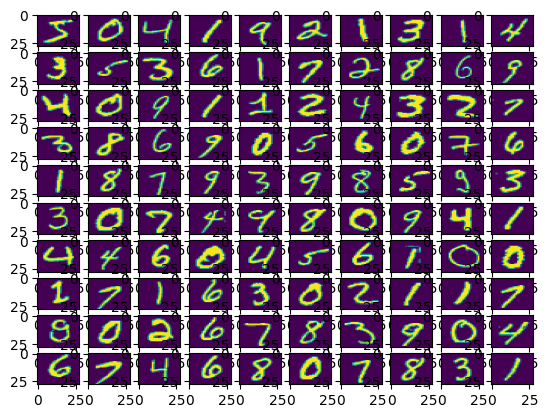

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

gray_scale = 255

x_train = x_train.astype('float32') / gray_scale
x_test = x_test.astype('float32') / gray_scale

print("Feature matrix (x_train):", x_train.shape)
print("Target matrix (y_train):", y_train.shape)
print("Feature matrix (x_test):", x_test.shape)
print("Target matrix (y_test):", y_test.shape)

fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k].reshape(28, 28), aspect='auto')
        k += 1
plt.show()

## Tensorflow Implementation

In this section I will implement a simple Multilayer Perceptron (MLP) using Tensorflow. The MLP will consist of an input layer, two hidden layers, and an output layer. We will use the ReLU activation function for the hidden layers and the Sigmoid activation function for the output layer.

In [3]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='sigmoid'),  
    Dense(128, activation='sigmoid'), 
    Dense(10, activation='softmax'),  
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
mod = model.fit(x_train, y_train, epochs=10, 
          batch_size=2000, 
          validation_split=0.2)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4122 - loss: 2.0524 - val_accuracy: 0.6983 - val_loss: 1.6827
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7224 - loss: 1.3437 - val_accuracy: 0.8029 - val_loss: 0.9978
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8208 - loss: 0.8364 - val_accuracy: 0.8670 - val_loss: 0.6522
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8665 - loss: 0.5884 - val_accuracy: 0.8921 - val_loss: 0.4821
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8890 - loss: 0.4600 - val_accuracy: 0.9053 - val_loss: 0.3942
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9001 - loss: 0.3899 - val_accuracy: 0.9106 - val_loss: 0.3457
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9068 - loss: 0.3474 - val_accuracy: 0.9155 - val_loss: 0.3135
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9136 - loss: 0.3175 - val_accuracy: 0.9204 - v

In [4]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705,440 (2.69 MB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 470,294 (1.79 MB)

In [5]:
results = model.evaluate(x_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

Test loss, Test accuracy: [0.2639405131340027, 0.926800012588501]


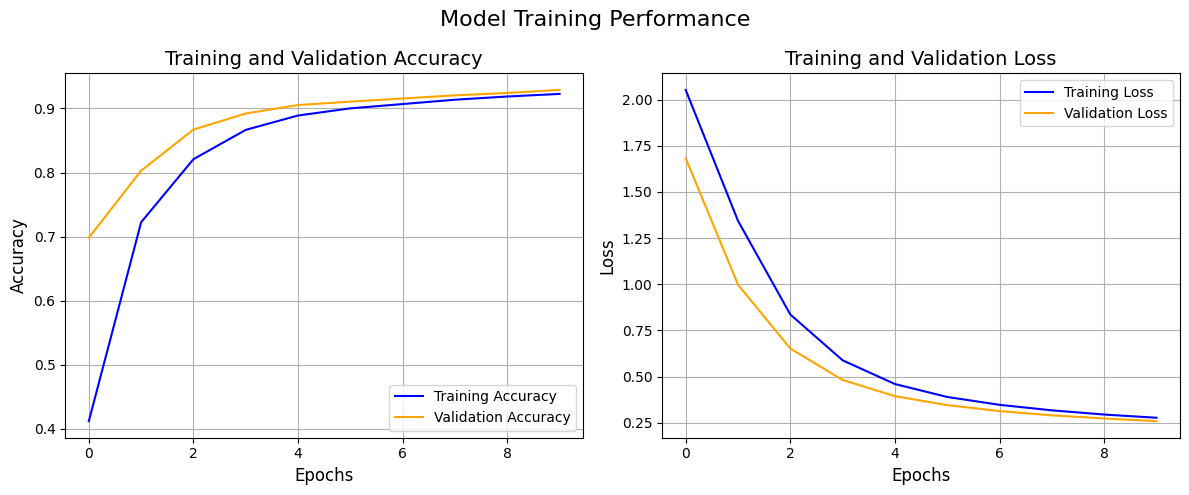

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'],
         label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()

## Basic Multilayer Perceptron Implementation

In this section I use a MLP from scratch for the same use case as the previous section. The architecture of the MLP is the same as the one implemented before with Tensorflow.

In [7]:
from src.perceptron import NeuralNetwork, Layer
nn = NeuralNetwork(input_neurons = 784) 
nn.add_layer(layer_neurons = 256, activation = "sigmoid")
nn.add_layer(layer_neurons = 128, activation = "sigmoid")
nn.add_layer(layer_neurons = 10, activation = "softmax")
nn.initialize_nn(learning_rate = 0.001)

Number of parameters: 235146


In [7]:
# Dataset.
# Flatten 28×28 → 784
x_train = x_train.reshape(len(x_train), -1)
x_test  = x_test.reshape(len(x_test),  -1)

print("x_train:", x_train.shape, "  y_train:", y_train.shape)
print("x_test :", x_test.shape,  "  y_test :", y_test.shape)

# Fit the NN.
nn.fit(x_train, y_train, epochs=50, batch_size=16, validation_data=(x_test, y_test))

x_train: (60000, 784)   y_train: (60000,)
x_test : (10000, 784)   y_test : (10000,)
Epoch 1/50  loss=2.3127  acc=0.1134  val_loss=2.3011  val_acc=0.1135
Epoch 2/50  loss=2.3028  acc=0.1126  val_loss=2.3058  val_acc=0.1135
Epoch 3/50  loss=2.3000  acc=0.1257  val_loss=2.2898  val_acc=0.1620
Epoch 4/50  loss=2.2909  acc=0.1378  val_loss=2.2961  val_acc=0.1128
Epoch 5/50  loss=2.2950  acc=0.1398  val_loss=2.2939  val_acc=0.1141
Epoch 6/50  loss=2.2947  acc=0.1268  val_loss=2.2952  val_acc=0.1155
Epoch 7/50  loss=2.2962  acc=0.1248  val_loss=2.2980  val_acc=0.1137
Epoch 8/50  loss=2.2977  acc=0.1122  val_loss=2.2964  val_acc=0.1137
Epoch 9/50  loss=2.2976  acc=0.1123  val_loss=2.2952  val_acc=0.1135
Epoch 10/50  loss=2.2925  acc=0.1195  val_loss=2.2884  val_acc=0.1135
Epoch 11/50  loss=2.2906  acc=0.1207  val_loss=2.2937  val_acc=0.1135
Epoch 12/50  loss=2.2971  acc=0.1153  val_loss=2.2965  val_acc=0.1161
Epoch 13/50  loss=2.2972  acc=0.1154  val_loss=2.2974  val_acc=0.1135
Epoch 14/50  lo

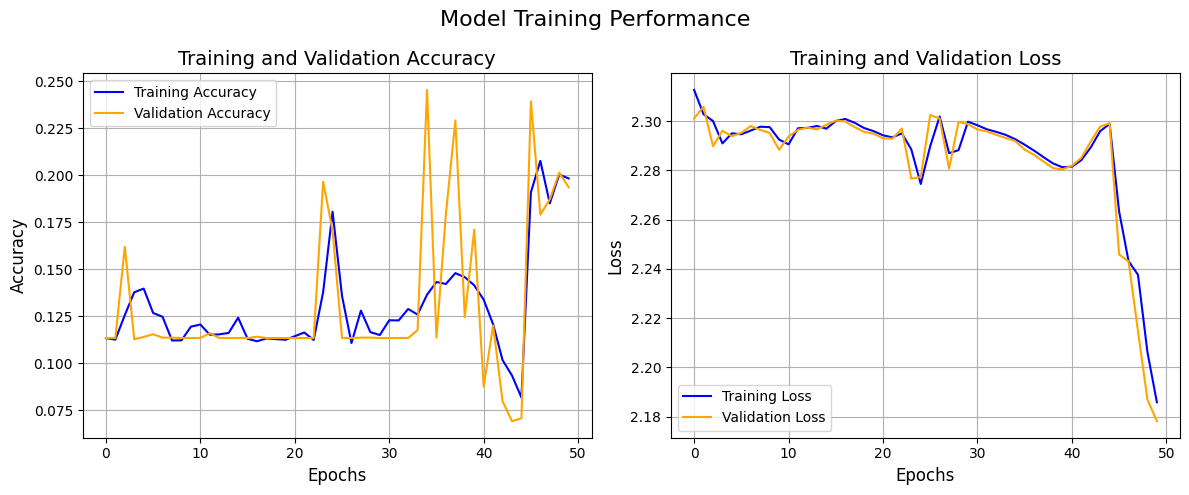

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(nn.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(nn.history['val_accuracy'],
         label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(nn.history['loss'], label='Training Loss', color='blue')
plt.plot(nn.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()